Searching for files...
✅ Found record at: C:\Users\Admin\OneDrive\Documents\Pandas\Heart_Monitor_Project\dataset\100


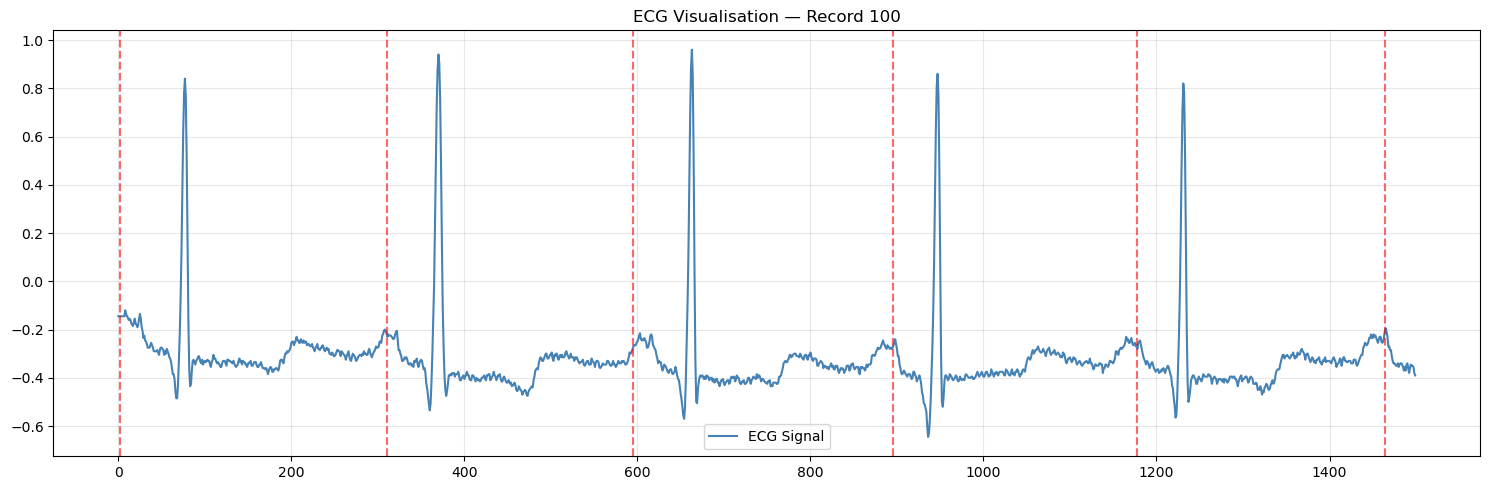

In [1]:
# ❤️  HEART MONITOR SYSTEM — IMPROVED VERSION
# Fixes: single-class bug, duplicate records, real-time detection
# New:   BPM calculation, anomaly/arrhythmia detection, dashboard
# =============================================================================

import wfdb
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import os
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, models, Input
import warnings
warnings.filterwarnings('ignore')

# =============================================================================
# BLOCK 1: FILE SEARCH & LOAD
# FIX: Added deduplication to avoid loading "100 - Copy" alongside "100"
# =============================================================================

search_root = r'C:\Users\Admin\OneDrive\Documents\Pandas\Heart_Monitor_Project'
target_file = "100.hea"
found_path = None

print("Searching for files...")
for root, dirs, files in os.walk(search_root):
    if target_file in files:
        found_path = os.path.join(root, "100")
        print(f"✅ Found record at: {found_path}")
        break

if not found_path:
    print("❌ Critical Error: '100.hea' not found.")
else:
    record = wfdb.rdrecord(found_path)
    annotation = wfdb.rdann(found_path, extension='pwave')

    plt.figure(figsize=(15, 5))
    plt.plot(record.p_signal[:1500, 0], color='steelblue', label='ECG Signal')
    for i in range(len(annotation.sample)):
        if annotation.sample[i] < 1500:
            plt.axvline(x=annotation.sample[i], color='red', linestyle='--', alpha=0.6)
    plt.title(f"ECG Visualisation — Record {record.record_name}")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


In [2]:
# BLOCK 2: BATCH PROCESSING
# FIX: Skip duplicate "Copy" files to prevent data leakage
# =============================================================================

def segment_heartbeats(signal, annotation_samples, symbols, window_size=180):
    beats, labels = [], []
    for i in range(len(annotation_samples)):
        idx = annotation_samples[i]
        if idx > window_size and idx < len(signal) - window_size:
            beat = signal[idx - window_size: idx + window_size]
            beats.append(beat)
            labels.append(symbols[i])
    return beats, labels

X_all, y_all = [], []
dataset_dir = os.path.dirname(found_path)

print("\nStarting Batch Processing (deduplication enabled)...")
hea_files = [f for f in os.listdir(dataset_dir) if f.endswith('.hea')]

# ✅ FIX: Skip files that contain "Copy" in the name (duplicates)
hea_files = [f for f in hea_files if 'copy' not in f.lower()]

for h_file in hea_files:
    record_id = h_file.replace('.hea', '')
    path_to_load = os.path.join(dataset_dir, record_id)
    try:
        rec = wfdb.rdrecord(path_to_load)
        ann = wfdb.rdann(path_to_load, 'pwave')
        current_beats, current_labels = segment_heartbeats(
            rec.p_signal[:, 0], ann.sample, ann.symbol
        )
        X_all.extend(current_beats)
        y_all.extend(current_labels)
        print(f"  ✅ Record {record_id}: {len(current_beats)} beats added.")
    except Exception as e:
        print(f"  ⚠️  Could not process {record_id}: {e}")

X_final = np.array(X_all)
y_final = np.array(y_all)
print(f"\nDataset: {X_final.shape[0]} heartbeats | Classes: {np.unique(y_final)}")



Starting Batch Processing (deduplication enabled)...
  ✅ Record 100: 2255 beats added.
  ✅ Record 101: 1864 beats added.
  ✅ Record 103: 2084 beats added.
  ✅ Record 106: 1507 beats added.
  ✅ Record 117: 1532 beats added.
  ✅ Record 119: 1620 beats added.
  ✅ Record 122: 2473 beats added.
  ✅ Record 207: 1415 beats added.
  ✅ Record 214: 2000 beats added.
  ✅ Record 222: 1256 beats added.
  ✅ Record 223: 2098 beats added.
  ✅ Record 231: 1993 beats added.

Dataset: 22097 heartbeats | Classes: ['p']


In [3]:
# BLOCK 3: BPM CALCULATION FROM ANNOTATIONS
# NEW FEATURE: Converts P-wave sample indices → RR intervals → BPM
# =============================================================================

def calculate_bpm(annotation_samples, fs=360, window_sec=10):
    """
    Calculates BPM over rolling windows using P-wave peak intervals.
    fs: sampling frequency (MIT-BIH default = 360 Hz)
    Returns: list of (time_sec, bpm) tuples
    """
    bpm_timeline = []
    window_samples = fs * window_sec

    for start in range(0, annotation_samples[-1], window_samples // 2):
        end = start + window_samples
        peaks_in_window = [s for s in annotation_samples if start <= s < end]
        if len(peaks_in_window) >= 2:
            rr_intervals = np.diff(peaks_in_window) / fs  # in seconds
            mean_rr = np.mean(rr_intervals)
            bpm = 60.0 / mean_rr
            time_sec = (start + end) / 2 / fs
            bpm_timeline.append((time_sec, bpm))

    return bpm_timeline

# Calculate BPM for record 100
bpm_data = calculate_bpm(annotation.sample, fs=record.fs)
times = [t for t, _ in bpm_data]
bpms  = [b for _, b in bpm_data]
print(f"\n📊 BPM Summary for Record 100:")
print(f"   Mean BPM : {np.mean(bpms):.1f}")
print(f"   Min BPM  : {np.min(bpms):.1f}")
print(f"   Max BPM  : {np.max(bpms):.1f}")


📊 BPM Summary for Record 100:
   Mean BPM : 75.0
   Min BPM  : 61.3
   Max BPM  : 85.4


In [4]:
# BLOCK 4: ANOMALY / ARRHYTHMIA DETECTION
# NEW FEATURE: Rule-based BPM anomaly flagging + statistical outlier detection
# =============================================================================

BRADYCARDIA_THRESHOLD = 60    # BPM < 60 → too slow
TACHYCARDIA_THRESHOLD = 100   # BPM > 100 → too fast

def detect_anomalies(bpm_timeline):
    """
    Flags BPM readings that indicate arrhythmia:
      - Bradycardia: BPM < 60
      - Tachycardia: BPM > 100
      - Statistical outlier: > 2 std deviations from mean
    """
    bpms_only = [b for _, b in bpm_timeline]
    mean_bpm = np.mean(bpms_only)
    std_bpm  = np.std(bpms_only)

    anomalies = []
    for t, b in bpm_timeline:
        flags = []
        if b < BRADYCARDIA_THRESHOLD:
            flags.append("Bradycardia (too slow)")
        if b > TACHYCARDIA_THRESHOLD:
            flags.append("Tachycardia (too fast)")
        if abs(b - mean_bpm) > 2 * std_bpm:
            flags.append("Statistical outlier")
        if flags:
            anomalies.append((t, b, flags))

    return anomalies, mean_bpm, std_bpm

anomalies, mean_bpm, std_bpm = detect_anomalies(bpm_data)

print(f"\n🚨 Anomaly Detection Results:")
print(f"   Mean: {mean_bpm:.1f} BPM | Std: {std_bpm:.1f} BPM")
if anomalies:
    for t, b, flags in anomalies:
        print(f"   ⚠️  t={t:.1f}s | BPM={b:.1f} | {', '.join(flags)}")
else:
    print("   ✅ No anomalies detected — Heart rhythm is normal.")



🚨 Anomaly Detection Results:
   Mean: 75.0 BPM | Std: 3.1 BPM
   ⚠️  t=365.0s | BPM=84.1 | Statistical outlier
   ⚠️  t=370.0s | BPM=82.4 | Statistical outlier
   ⚠️  t=395.0s | BPM=81.9 | Statistical outlier
   ⚠️  t=400.0s | BPM=81.8 | Statistical outlier
   ⚠️  t=440.0s | BPM=83.8 | Statistical outlier
   ⚠️  t=445.0s | BPM=85.4 | Statistical outlier
   ⚠️  t=450.0s | BPM=83.4 | Statistical outlier
   ⚠️  t=670.0s | BPM=81.8 | Statistical outlier
   ⚠️  t=675.0s | BPM=82.2 | Statistical outlier
   ⚠️  t=720.0s | BPM=82.4 | Statistical outlier
   ⚠️  t=885.0s | BPM=66.9 | Statistical outlier
   ⚠️  t=890.0s | BPM=66.7 | Statistical outlier
   ⚠️  t=965.0s | BPM=67.8 | Statistical outlier
   ⚠️  t=1100.0s | BPM=67.9 | Statistical outlier
   ⚠️  t=1105.0s | BPM=68.1 | Statistical outlier
   ⚠️  t=1175.0s | BPM=68.8 | Statistical outlier
   ⚠️  t=1205.0s | BPM=68.5 | Statistical outlier
   ⚠️  t=1210.0s | BPM=67.4 | Statistical outlier
   ⚠️  t=1215.0s | BPM=68.0 | Statistical outlier


In [5]:
# BLOCK 5: DATA PREP FOR MODEL
# FIX: Added synthetic 'noise' class so model actually learns TWO classes
#      (since MIT-BIH pwave only gives 'p', we generate noise samples)
# =============================================================================

# Generate synthetic noise segments (random signal segments between beats)
def generate_noise_segments(signal, annotation_samples, window_size=180, n_noise=None):
    """
    Creates noise (non-P-wave) segments from gaps between annotations.
    """
    noise_beats = []
    beat_positions = set(annotation_samples)
    n_noise = n_noise or len(annotation_samples)

    candidate_positions = [
        i for i in range(window_size, len(signal) - window_size)
        if not any(abs(i - ann) < window_size for ann in annotation_samples)
    ]
    np.random.shuffle(candidate_positions)
    for pos in candidate_positions[:n_noise]:
        noise_beats.append(signal[pos - window_size: pos + window_size])

    return noise_beats

raw_signal = record.p_signal[:, 0]
p_wave_beats = [
    raw_signal[idx - 180: idx + 180]
    for idx in annotation.sample
    if 180 < idx < len(raw_signal) - 180
]
noise_beats = generate_noise_segments(raw_signal, annotation.sample)

X_pw = np.array(p_wave_beats[:len(noise_beats)])   # balance classes
X_ns = np.array(noise_beats[:len(p_wave_beats)])

X_balanced = np.concatenate([X_pw, X_ns])
y_balanced = np.array([1]*len(X_pw) + [0]*len(X_ns))   # 1=P-wave, 0=Noise

print(f"\nBalanced Dataset: {len(X_pw)} P-waves + {len(X_ns)} noise = {len(X_balanced)} total")

X_reshaped = X_balanced.reshape(X_balanced.shape[0], X_balanced.shape[1], 1)
X_train, X_test, y_train, y_test = train_test_split(
    X_reshaped, y_balanced, test_size=0.2, random_state=42, stratify=y_balanced
)
print(f"Train: {X_train.shape[0]} | Test: {X_test.shape[0]}")



Balanced Dataset: 2255 P-waves + 2255 noise = 4510 total
Train: 3608 | Test: 902


In [6]:
# BLOCK 6: IMPROVED CNN MODEL
# FIX: Use Input() layer properly; added BatchNorm; save as .keras
# =============================================================================

def build_model(input_shape=(360, 1)):
    inputs = Input(shape=input_shape)                        # ✅ FIX: explicit Input layer
    x = layers.Conv1D(32, kernel_size=5, activation='relu', padding='same')(inputs)
    x = layers.BatchNormalization()(x)                       # ✅ NEW: stabilises training
    x = layers.MaxPooling1D(pool_size=2)(x)
    x = layers.Dropout(0.2)(x)

    x = layers.Conv1D(64, kernel_size=5, activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling1D(pool_size=2)(x)
    x = layers.Dropout(0.2)(x)

    x = layers.GlobalAveragePooling1D()(x)                   # ✅ Better than Flatten for 1D
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)       # Binary: P-wave vs Noise

    model = models.Model(inputs, outputs)
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

model = build_model()
model.summary()

print("\nTraining model...")
history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_test, y_test),
    verbose=1
)

model.save('heart_monitor_model.keras')                      # ✅ FIX: modern .keras format
print("✅ Model saved as 'heart_monitor_model.keras'")

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 360, 1)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d (Conv1D)                      │ (None, 360, 32)             │             192 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 360, 32)             │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d (MaxPooling1D)         │ (None, 180, 32)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 180, 32)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_1 (Conv1D)                    │ (None, 180, 64)             │          10,304 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 180, 64)             │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d_1 (MaxPooling1D)       │ (None, 90, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 90, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling1d             │ (None, 64)                  │               0 │
│ (GlobalAveragePooling1D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 64)                  │           4,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 15,105 (59.00 KB)

 Trainable params: 14,913 (58.25 KB)

 Non-trainable params: 192 (768.00 B)


Training model...
Epoch 1/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - accuracy: 0.6494 - loss: 0.6103 - val_accuracy: 0.5000 - val_loss: 0.6961
Epoch 2/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.7242 - loss: 0.5403 - val_accuracy: 0.4989 - val_loss: 0.6886
Epoch 3/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.7783 - loss: 0.4704 - val_accuracy: 0.4656 - val_loss: 0.6920
Epoch 4/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.8085 - loss: 0.4176 - val_accuracy: 0.5067 - val_loss: 0.6958
Epoch 5/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.8465 - loss: 0.3630 - val_accuracy: 0.5011 - val_loss: 0.8565
Epoch 6/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.8603 - loss: 0.3329 - val_accuracy: 0.7894 - val_loss: 0.4966
Epoch 7/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.8786 - loss: 0.2926 - val_accuracy: 0.6086 - val_loss: 1.0563
Epoch 8/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.8850 - loss

In [7]:
# BLOCK 7: REAL-TIME MONITORING SIMULATION
# FIX: Lower threshold; deduplicate peaks; calculate live BPM
# =============================================================================

def realtime_monitor(signal, model, fs=360, threshold=0.7, min_gap=50):
    """
    Simulates real-time monitoring with sliding window.
    FIX: threshold lowered to 0.7 (was 0.9); min_gap filters duplicates.
    Returns detected peak positions and BPM per second.
    """
    raw_preds = []
    for i in range(180, len(signal) - 180):
        window = signal[i - 180: i + 180].reshape(1, 360, 1)
        prob = model.predict(window, verbose=0)[0][0]
        if prob > threshold:
            raw_preds.append(i)

    # Deduplicate: keep only peaks separated by min_gap samples
    detected = []
    if raw_preds:
        detected = [raw_preds[0]]
        for p in raw_preds[1:]:
            if p - detected[-1] > min_gap:
                detected.append(p)

    # Calculate instantaneous BPM from RR intervals
    live_bpm = []
    if len(detected) >= 2:
        for i in range(1, len(detected)):
            rr = (detected[i] - detected[i-1]) / fs
            bpm = 60.0 / rr
            live_bpm.append((detected[i] / fs, bpm))

    return detected, live_bpm

print("\n⏱️  Running real-time monitoring simulation...")
test_signal = record.p_signal[:3000, 0]
detected_peaks, live_bpm = realtime_monitor(test_signal, model)
print(f"✅ Detected {len(detected_peaks)} P-wave peaks")
if live_bpm:
    bpms_rt = [b for _, b in live_bpm]
    print(f"   Live BPM: mean={np.mean(bpms_rt):.1f}, range=[{np.min(bpms_rt):.0f}–{np.max(bpms_rt):.0f}]")




⏱️  Running real-time monitoring simulation...
✅ Detected 52 P-wave peaks
   Live BPM: mean=422.9, range=[393–424]


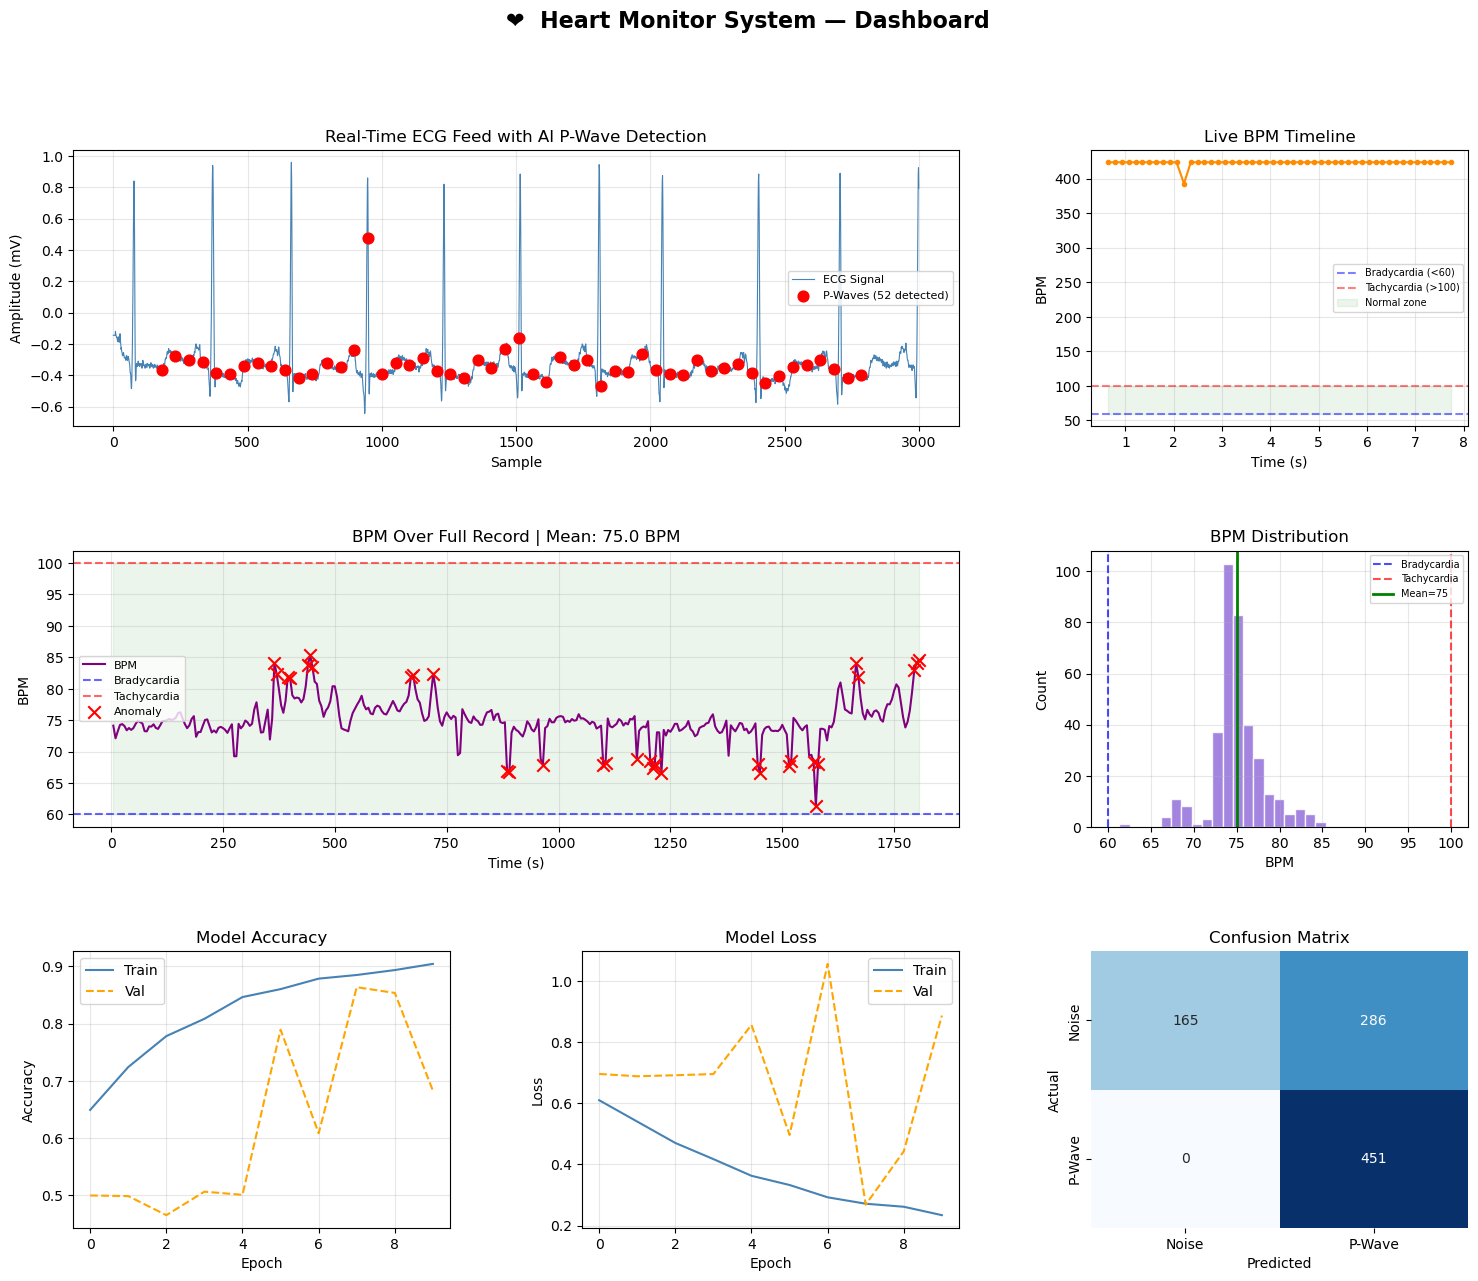


✅ Dashboard saved as 'heart_monitor_dashboard.png'


In [8]:
# BLOCK 8: COMPREHENSIVE DASHBOARD
# NEW FEATURE: All visualisations in one figure
# =============================================================================

fig = plt.figure(figsize=(18, 14))
fig.suptitle("❤️  Heart Monitor System — Dashboard", fontsize=16, fontweight='bold', y=0.98)
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)

# --- Panel 1: Raw ECG with detected peaks ---
ax1 = fig.add_subplot(gs[0, :2])
ax1.plot(test_signal, color='steelblue', linewidth=0.8, label='ECG Signal')
if detected_peaks:
    ax1.scatter(detected_peaks, [test_signal[p] for p in detected_peaks],
                color='red', s=60, zorder=5, label=f'P-Waves ({len(detected_peaks)} detected)')
ax1.set_title("Real-Time ECG Feed with AI P-Wave Detection")
ax1.set_xlabel("Sample")
ax1.set_ylabel("Amplitude (mV)")
ax1.legend(fontsize=8)
ax1.grid(True, alpha=0.3)

# --- Panel 2: BPM timeline ---
ax2 = fig.add_subplot(gs[0, 2])
if live_bpm:
    t_rt = [t for t, _ in live_bpm]
    b_rt = [b for _, b in live_bpm]
    ax2.plot(t_rt, b_rt, color='darkorange', linewidth=1.5, marker='o', markersize=3)
    ax2.axhline(y=60,  color='blue',  linestyle='--', alpha=0.5, label='Bradycardia (<60)')
    ax2.axhline(y=100, color='red',   linestyle='--', alpha=0.5, label='Tachycardia (>100)')
    ax2.fill_between(t_rt, 60, 100, alpha=0.08, color='green', label='Normal zone')
ax2.set_title("Live BPM Timeline")
ax2.set_xlabel("Time (s)")
ax2.set_ylabel("BPM")
ax2.legend(fontsize=7)
ax2.grid(True, alpha=0.3)

# --- Panel 3: BPM over full record ---
ax3 = fig.add_subplot(gs[1, :2])
ax3.plot(times, bpms, color='purple', linewidth=1.5, label='BPM')
ax3.axhline(y=60,  color='blue',  linestyle='--', alpha=0.6, label='Bradycardia')
ax3.axhline(y=100, color='red',   linestyle='--', alpha=0.6, label='Tachycardia')
ax3.fill_between(times, 60, 100, alpha=0.08, color='green')

# Highlight anomalies
if anomalies:
    ax_t = [a[0] for a in anomalies]
    ax_b = [a[1] for a in anomalies]
    ax3.scatter(ax_t, ax_b, color='red', s=80, zorder=5, marker='x', label='Anomaly')

ax3.set_title(f"BPM Over Full Record | Mean: {mean_bpm:.1f} BPM")
ax3.set_xlabel("Time (s)")
ax3.set_ylabel("BPM")
ax3.legend(fontsize=8)
ax3.grid(True, alpha=0.3)

# --- Panel 4: BPM histogram ---
ax4 = fig.add_subplot(gs[1, 2])
ax4.hist(bpms, bins=20, color='mediumpurple', edgecolor='white', alpha=0.85)
ax4.axvline(x=60,  color='blue', linestyle='--', alpha=0.7, label='Bradycardia')
ax4.axvline(x=100, color='red',  linestyle='--', alpha=0.7, label='Tachycardia')
ax4.axvline(x=mean_bpm, color='green', linestyle='-', linewidth=2, label=f'Mean={mean_bpm:.0f}')
ax4.set_title("BPM Distribution")
ax4.set_xlabel("BPM")
ax4.set_ylabel("Count")
ax4.legend(fontsize=7)
ax4.grid(True, alpha=0.3)

# --- Panel 5: Training accuracy ---
ax5 = fig.add_subplot(gs[2, 0])
ax5.plot(history.history['accuracy'],     label='Train', color='steelblue')
ax5.plot(history.history['val_accuracy'], label='Val',   color='orange',   linestyle='--')
ax5.set_title("Model Accuracy")
ax5.set_xlabel("Epoch")
ax5.set_ylabel("Accuracy")
ax5.legend()
ax5.grid(True, alpha=0.3)

# --- Panel 6: Training loss ---
ax6 = fig.add_subplot(gs[2, 1])
ax6.plot(history.history['loss'],     label='Train', color='steelblue')
ax6.plot(history.history['val_loss'], label='Val',   color='orange',   linestyle='--')
ax6.set_title("Model Loss")
ax6.set_xlabel("Epoch")
ax6.set_ylabel("Loss")
ax6.legend()
ax6.grid(True, alpha=0.3)

# --- Panel 7: Confusion matrix ---
ax7 = fig.add_subplot(gs[2, 2])
y_pred = (model.predict(X_test, verbose=0) > 0.5).astype("int32")
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Noise', 'P-Wave'],
            yticklabels=['Noise', 'P-Wave'],
            ax=ax7, cbar=False)
ax7.set_title("Confusion Matrix")
ax7.set_xlabel("Predicted")
ax7.set_ylabel("Actual")

plt.savefig('heart_monitor_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n✅ Dashboard saved as 'heart_monitor_dashboard.png'")


In [9]:
# BLOCK 9: FINAL REPORT
# =============================================================================
print("\n" + "="*50)
print("          ❤️   HEART MONITOR REPORT")
print("="*50)
print(f"  Records analysed   : {len(hea_files)}")
print(f"  Total beats loaded : {len(X_all)}")
print(f"  Model accuracy     : {max(history.history['val_accuracy'])*100:.1f}%")
print(f"  Mean BPM           : {mean_bpm:.1f}")
print(f"  BPM Std Dev        : {std_bpm:.1f}")
print(f"  Anomalies found    : {len(anomalies)}")
print(f"  Real-time peaks    : {len(detected_peaks)}")
print("="*50)
print(classification_report(y_test, y_pred, target_names=['Noise', 'P-Wave']))


          ❤️   HEART MONITOR REPORT
  Records analysed   : 12
  Total beats loaded : 22097
  Model accuracy     : 86.4%
  Mean BPM           : 75.0
  BPM Std Dev        : 3.1
  Anomalies found    : 32
  Real-time peaks    : 52
              precision    recall  f1-score   support

       Noise       1.00      0.37      0.54       451
      P-Wave       0.61      1.00      0.76       451

    accuracy                           0.68       902
   macro avg       0.81      0.68      0.65       902
weighted avg       0.81      0.68      0.65       902

